In [309]:
import pandas as pd
import pybedtools
import re
import os
import numpy as np

In [4]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

In [6]:
illumina_file = [x.split('.')[0] for x in os.listdir('/data1/DYY/bambu/illumina/bed/')]

In [265]:
illumina_file.to_csv('/data1/DYY/bambu/illumina/illumina_sampleslist.txt',header=False,index=False)

In [8]:
illumina_file = pd.DataFrame(illumina_file,columns=['Sample'])

In [10]:
group = pd.read_csv('/data1/DYY/bambu/350_samples_group.csv',sep='\t')

In [12]:
groupby = illumina_file.rename(columns={0:'Sample'}).merge(group).groupby('Sample ID')

In [16]:
classification = pd.read_csv('/data1/DYY/bambu/sqanti3_output/bambu_classification.txt',sep='\t')

In [22]:
fsm = classification.loc[classification.structural_category=='full-splice_match'][['isoform']]
nic = classification.loc[classification.structural_category=='novel_in_catalog'][['isoform']]
nnc = classification.loc[classification.structural_category=='novel_not_in_catalog'][['isoform']]

In [36]:
counts_trans = pd.read_csv('/data1/DYY/bambu/counts_transcript.txt',sep='\t').set_index(['TXNAME']).loc[:,illumina_file['Sample']]

In [285]:
fsm_bambu = counts_trans.loc[fsm['isoform']]
fsm_iso = fsm_bambu[fsm_bambu.sum(axis=1)>1].index.tolist()
nic_bambu = counts_trans.loc[nic['isoform']]
nic_iso = nic_bambu[nic_bambu.sum(axis=1)>1].index.tolist()
nnc_bambu = counts_trans.loc[nnc['isoform']]
nnc_iso = nnc_bambu[nnc_bambu.sum(axis=1)>1].index.tolist()

    # sample_dict['fsm'] = 

In [106]:
illumina_df = pd.DataFrame()
for i in illumina_file.Sample:
    illumina_data = pd.read_csv(f'/data1/DYY/bambu/illumina/bed/{i}.junction.bed',sep='\t',header=None)
    illumina_data = illumina_data.loc[illumina_data[4]>=1]
    illumina_data = illumina_data[[0,1,2]]
    illumina_data.columns=['chromosome','donor','acceptor']
    # 向量化操作生成 donor 和 acceptor 范围
    donor_sites = pd.DataFrame({
        "chromosome": illumina_data["chromosome"],
        "site_s": illumina_data["donor"] - 5,
        "site_e": illumina_data["donor"] + 5
    })
    donor_sites.site_s = donor_sites.site_s.clip(lower=0)
    acceptor_sites = pd.DataFrame({
        "chromosome": illumina_data["chromosome"],
        "site_s": illumina_data["acceptor"] - 5,
        "site_e": illumina_data["acceptor"] + 5
    })
    acceptor_sites.site_s = acceptor_sites.site_s.clip(lower=0)
    # 合并 donor 和 acceptor 范围
    result_df = pd.concat([donor_sites, acceptor_sites], ignore_index=True)
    result_df = result_df.sort_values(['chromosome','site_s'])
    try:
        illumina_df = pd.concat([illumina_df,result_df])
    except:
        illumina_df = result_df.copy()

In [112]:
illumina_df = illumina_df.drop_duplicates()

In [120]:
illumina = BedTool.from_dataframe(illumina_df.sort_values(['chromosome','site_s']))

In [124]:
merged_illumina = illumina.merge()

In [64]:
bambu_gtf = pybedtools.BedTool('/data1/DYY/bambu/extended_annotations.gtf')

In [215]:
import re
import pandas as pd

def extract_junctions_with_chromosome(gtf_data):
    # Filter for exons only
    exons = gtf_data.filter(lambda x: x[2] == "exon").saveas()

    # Convert to DataFrame
    df = exons.to_dataframe()

    # Extract transcript_id from the "attribute" column
    def get_transcript_id(attributes):
        match = re.search(r'transcript_id "([^"]+)"', attributes)
        return match.group(1) if match else None

    df['transcript_id'] = df['attributes'].apply(get_transcript_id)

    # Drop rows without a transcript_id (in case of missing data)
    df = df.dropna(subset=['transcript_id'])

    # Sort by transcript_id and start
    df = df.sort_values(by=["transcript_id", "start"])

    # Parse exon data and extract junctions
    junctions = []
    for transcript_id, transcript_data in df.groupby("transcript_id"):
        exon_starts = transcript_data["start"].tolist()
        exon_ends = transcript_data["end"].tolist()
        chromosome = transcript_data["seqname"].iloc[0]  # Assuming all exons of a transcript are on the same chromosome

        # Skip the first and last exons by iterating from the second exon to the second-to-last exon
        for i in range(1, len(exon_starts) ):
            # Append donor (end of current exon) and acceptor (start of next exon)
            junctions.append((chromosome, transcript_id, exon_ends[i - 1], exon_starts[i]))

    # Convert junctions to DataFrame
    return pd.DataFrame(junctions, columns=["chromosome", "transcript_id", "donor", "acceptor"])


In [217]:
bambu_splicing_sites = extract_junctions_with_chromosome(bambu_gtf)

In [223]:
from pybedtools import BedTool
import warnings
warnings.filterwarnings('ignore')

In [287]:
fsm_splicing_sites = bambu_splicing_sites[bambu_splicing_sites.transcript_id.isin(fsm_iso)]
nic_splicing_sites = bambu_splicing_sites[bambu_splicing_sites.transcript_id.isin(nic_iso)]
nnc_splicing_sites = bambu_splicing_sites[bambu_splicing_sites.transcript_id.isin(nnc_iso)]


In [289]:
fsm_df = BedTool.from_dataframe(fsm_splicing_sites[['chromosome','donor','acceptor','transcript_id']])
nic_df = BedTool.from_dataframe(nic_splicing_sites[['chromosome','donor','acceptor','transcript_id']])
nnc_df = BedTool.from_dataframe(nnc_splicing_sites[['chromosome','donor','acceptor','transcript_id']])

fsm_illumina_intersect = fsm_df.intersect(merged_illumina,wa=True).to_dataframe().drop_duplicates()
nic_illumina_intersect = nic_df.intersect(merged_illumina,wa=True).to_dataframe().drop_duplicates()
nnc_illumina_intersect = nnc_df.intersect(merged_illumina,wa=True).to_dataframe().drop_duplicates()

***** WARNING: File /tmp/pybedtools.3g8oqa2l.tmp has inconsistent naming convention for record:
chr1	10626	10636

***** WARNING: File /tmp/pybedtools.3g8oqa2l.tmp has inconsistent naming convention for record:
chr1	10626	10636

***** WARNING: File /tmp/pybedtools.3g8oqa2l.tmp has inconsistent naming convention for record:
chr1	10626	10636

***** WARNING: File /tmp/pybedtools.3g8oqa2l.tmp has inconsistent naming convention for record:
chr1	10626	10636

***** WARNING: File /tmp/pybedtools.3g8oqa2l.tmp has inconsistent naming convention for record:
chr1	10626	10636

***** WARNING: File /tmp/pybedtools.3g8oqa2l.tmp has inconsistent naming convention for record:
chr1	10626	10636



In [290]:
fsm_intersect = pd.DataFrame(data = fsm_illumina_intersect.groupby('name').count()['chrom'])
fsm_raw = pd.DataFrame(data = fsm_splicing_sites.groupby('transcript_id').count()['chromosome'])
nic_intersect = pd.DataFrame(data = nic_illumina_intersect.groupby('name').count()['chrom'])
nic_raw = pd.DataFrame(data = nic_splicing_sites.groupby('transcript_id').count()['chromosome'])
nnc_intersect = pd.DataFrame(data = nnc_illumina_intersect.groupby('name').count()['chrom'])
nnc_raw = pd.DataFrame(data = nnc_splicing_sites.groupby('transcript_id').count()['chromosome'])

In [291]:
fsm_merge = pd.concat([fsm_intersect,fsm_raw],axis=1).fillna(0)
nic_merge = pd.concat([nic_intersect,nic_raw],axis=1).fillna(0)
nnc_merge = pd.concat([nnc_intersect,nnc_raw],axis=1).fillna(0)

# 1e

In [301]:
sample_df=pd.DataFrame(index=illumina_file.Sample,columns=['FSM','NIC','NNC'])
for s in illumina_file['Sample']:
    sample_fsm =  fsm_bambu.loc[fsm_bambu[s]>=1].index.tolist()
    sample_nic = nic_bambu.loc[nic_bambu[s]>=1].index.tolist()
    sample_nnc = nnc_bambu.loc[nnc_bambu[s]>=1].index.tolist()
    fsm_splicing_sites = bambu_splicing_sites[bambu_splicing_sites.transcript_id.isin(sample_fsm)]
    nic_splicing_sites = bambu_splicing_sites[bambu_splicing_sites.transcript_id.isin(sample_nic)]
    nnc_splicing_sites = bambu_splicing_sites[bambu_splicing_sites.transcript_id.isin(sample_nnc)]
    fsm_df = BedTool.from_dataframe(fsm_splicing_sites[['chromosome','donor','acceptor','transcript_id']])
    nic_df = BedTool.from_dataframe(nic_splicing_sites[['chromosome','donor','acceptor','transcript_id']])
    nnc_df = BedTool.from_dataframe(nnc_splicing_sites[['chromosome','donor','acceptor','transcript_id']])
    
    fsm_illumina_intersect = fsm_df.intersect(merged_illumina,wa=True).to_dataframe().drop_duplicates()
    nic_illumina_intersect = nic_df.intersect(merged_illumina,wa=True).to_dataframe().drop_duplicates()
    nnc_illumina_intersect = nnc_df.intersect(merged_illumina,wa=True).to_dataframe().drop_duplicates()
    fsm_intersect = pd.DataFrame(data = fsm_illumina_intersect.groupby('name').count()['chrom'])
    fsm_raw = pd.DataFrame(data = fsm_splicing_sites.groupby('transcript_id').count()['chromosome'])
    nic_intersect = pd.DataFrame(data = nic_illumina_intersect.groupby('name').count()['chrom'])
    nic_raw = pd.DataFrame(data = nic_splicing_sites.groupby('transcript_id').count()['chromosome'])
    nnc_intersect = pd.DataFrame(data = nnc_illumina_intersect.groupby('name').count()['chrom'])
    nnc_raw = pd.DataFrame(data = nnc_splicing_sites.groupby('transcript_id').count()['chromosome'])
    fsm_merge = pd.concat([fsm_intersect,fsm_raw],axis=1).fillna(0)
    nic_merge = pd.concat([nic_intersect,nic_raw],axis=1).fillna(0)
    nnc_merge = pd.concat([nnc_intersect,nnc_raw],axis=1).fillna(0)
    fsm_ratio = len(fsm_merge[fsm_merge.chrom==fsm_merge.chromosome])/len(fsm_raw)
    nic_ratio = len(nic_merge[nic_merge.chrom==nic_merge.chromosome])/len(nic_raw)
    nnc_ratio = len(nnc_merge[nnc_merge.chrom==nnc_merge.chromosome])/len(nnc_raw)
    sample_df.loc[s,'FSM'] = fsm_ratio
    sample_df.loc[s,'NIC'] = nic_ratio
    sample_df.loc[s,'NNC'] = nnc_ratio
    # break

***** WARNING: File /tmp/pybedtools.3g8oqa2l.tmp has inconsistent naming convention for record:
chr1	10626	10636

***** WARNING: File /tmp/pybedtools.3g8oqa2l.tmp has inconsistent naming convention for record:
chr1	10626	10636

***** WARNING: File /tmp/pybedtools.3g8oqa2l.tmp has inconsistent naming convention for record:
chr1	10626	10636

***** WARNING: File /tmp/pybedtools.3g8oqa2l.tmp has inconsistent naming convention for record:
chr1	10626	10636

***** WARNING: File /tmp/pybedtools.3g8oqa2l.tmp has inconsistent naming convention for record:
chr1	10626	10636

***** WARNING: File /tmp/pybedtools.3g8oqa2l.tmp has inconsistent naming convention for record:
chr1	10626	10636

***** WARNING: File /tmp/pybedtools.3g8oqa2l.tmp has inconsistent naming convention for record:
chr1	10626	10636

***** WARNING: File /tmp/pybedtools.3g8oqa2l.tmp has inconsistent naming convention for record:
chr1	10626	10636

***** WARNING: File /tmp/pybedtools.3g8oqa2l.tmp has inconsistent naming convention for 

In [305]:
sample_df.to_csv('/data1/DYY/bambu/1e_data_fsm_nic_nnc_ratio.csv',sep='\t')

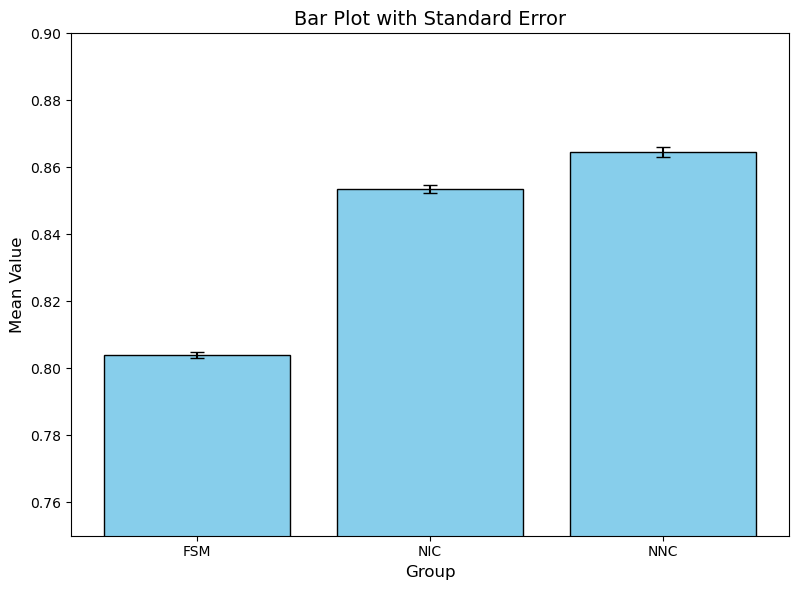

In [313]:
# 计算每个组的标准误差（标准差 / sqrt(n)）
se = sample_df.std() / np.sqrt(sample_df.count())

# 计算每个组的平均值
means = sample_df.mean()

# 绘制带有标准误差的柱状图
fig, ax = plt.subplots(figsize=(8, 6))

# 绘制柱状图，yerr表示误差条，capsize控制误差条的末端大小
bars = ax.bar(means.index, means.values, yerr=se.values, capsize=5, color='skyblue', edgecolor='black')

# 设置图形标题和标签
ax.set_title('Bar Plot with Standard Error', fontsize=14)
ax.set_ylabel('Mean Value', fontsize=12)
ax.set_xlabel('Group', fontsize=12)

# 显示图形
plt.tight_layout()
plt.ylim(0.75,.9)
plt.savefig('/data1/DYY/bambu/plot/figure1/1e.pdf',dpi=400)

In [ ]:
anno = pybedtools.BedTool('/data/DYY/pan-cancer/nanopore/gencode.v42.annotation.gtf').saveas("/data1/DYY/bambu/bambu_data/tmp/gencode.gtf")

In [378]:
for i in illumina_file.Sample:
    illumina_data = pd.read_csv(f'/data1/DYY/bambu/illumina/bed/{i}.junction.bed',sep='\t',header=None)
    illumina_data = illumina_data.loc[illumina_data[4]>=1]
    illumina_data = illumina_data[[0,1,2]]
    illumina_data.columns=['chromosome','donor','acceptor']
    # 向量化操作生成 donor 和 acceptor 范围
    donor_sites = pd.DataFrame({
        "chromosome": illumina_data["chromosome"],
        "site_s": illumina_data["donor"] - 5,
        "site_e": illumina_data["donor"] + 5
    })
    donor_sites.site_s = donor_sites.site_s.clip(lower=0)
    acceptor_sites = pd.DataFrame({
        "chromosome": illumina_data["chromosome"],
        "site_s": illumina_data["acceptor"] - 5,
        "site_e": illumina_data["acceptor"] + 5
    })
    acceptor_sites.site_s = acceptor_sites.site_s.clip(lower=0)
    # 合并 donor 和 acceptor 范围
    result_df = pd.concat([donor_sites, acceptor_sites], ignore_index=True)
    result_df = result_df.sort_values(['chromosome','site_s'])
    result_df.drop_duplicates().to_csv(f'/data/DYY/pan-cancer/splicing_site_bedfiles/{i}_illumina.bed',sep='\t',index=False,header=False)
    bambu_data = pd.read_csv('/data/DYY/pan-cancer/regtools/'+i,sep='\t',header=None)
    bambu_data = bambu_data.loc[bambu_data[4]>=2]
    bambu_data = bambu_data[[0,1,2]]
    bambu_data.columns=['chromosome','donor','acceptor']
    donor_sites = pd.DataFrame({
        "chromosome": bambu_data["chromosome"],
        "site_s": bambu_data["donor"] - 5,
        "site_e": bambu_data["donor"] + 5
    })
    donor_sites.site_s = donor_sites.site_s.clip(lower=0)
    acceptor_sites = pd.DataFrame({
        "chromosome": bambu_data["chromosome"],
        "site_s": bambu_data["acceptor"] - 5,
        "site_e": bambu_data["acceptor"] + 5
    })
    acceptor_sites.site_s = acceptor_sites.site_s.clip(lower=0)
    # 合并 donor 和 acceptor 范围
    result_df = pd.concat([donor_sites, acceptor_sites], ignore_index=True)
    result_df = result_df.sort_values(['chromosome','site_s'])
    result_df.drop_duplicates().to_csv(f'/data/DYY/pan-cancer/splicing_site_bedfiles/{i}_bambu.bed',sep='\t',index=False,header=False)
    # break

In [428]:
sum_df = pd.read_csv('/data/DYY/pan-cancer/splicing_site_bedfiles/merged/splicing_site_summary.tsv',sep='\t')

In [360]:
sum_df.loc[sum_df.Sample==i]

,Sample,Bambu_Row_Count,Illumina_Row_Count,Bambu_Intersect_Row_Count,Illumina_Intersect_Row_Count
31,A1801664J07TT2,651127,736653,236178,235117


In [390]:
ts_df = pd.read_csv('/data1/DYY/bambu/288_tumor_specific_trans/BRE',header=None)

In [394]:
ts_df = ts_df.loc[ts_df[0].str.startswith('ENST')]

In [406]:
ts_gtf = extract_junctions_with_chromosome(pybedtools.BedTool('/data1/DYY/bambu/extended_annotations.gtf'))

In [418]:
ts_gtf = ts_gtf.loc[ts_gtf.transcript_id.isin(ts_df[0])]

In [420]:
# bambu_data = bambu_data.loc[bambu_data[4]>=2]
# bambu_data = bambu_data[[0,1,2]]
bambu_data = ts_gtf[['chromosome','donor','acceptor']]
# bambu_data.columns=['chromosome','donor','acceptor']
donor_sites = pd.DataFrame({
    "chromosome": bambu_data["chromosome"],
    "site_s": bambu_data["donor"] - 5,
    "site_e": bambu_data["donor"] + 5
})
donor_sites.site_s = donor_sites.site_s.clip(lower=0)
acceptor_sites = pd.DataFrame({
    "chromosome": bambu_data["chromosome"],
    "site_s": bambu_data["acceptor"] - 5,
    "site_e": bambu_data["acceptor"] + 5
})
acceptor_sites.site_s = acceptor_sites.site_s.clip(lower=0)
# 合并 donor 和 acceptor 范围
result_df = pd.concat([donor_sites, acceptor_sites], ignore_index=True)
result_df = result_df.sort_values(['chromosome','site_s'])
result_df.drop_duplicates().to_csv(f'/data/DYY/pan-cancer/splicing_site_bedfiles/ts_bambu.bed',sep='\t',index=False,header=False)

In [436]:
sum_df.drop(32).to_csv('/data1/DYY/bambu/illumina/illumina_splicing_site_intersection_with_bambu.csv',sep='\t',index=False)